# Probablity and statistics related studies
Here I am showing the topic cover in probablity and statistics.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [3]:
# Performing data cleaning and preprocessing

df = pd.read_csv('../data/rawData.csv', header=None, index_col=False)

In [4]:
df.head() 

,0
0,| patient_id | age | gender | glucose | choles...
1,| ---------- | --: | ------ | ------: | ------...
2,| P001 | 25 | Male | 92 | ...
3,| P002 | 51 | Female | 145 | ...
4,| P003 | 34 | Male | 105 | ...


In [5]:
# 2. Filter out Markdown separator rows (like "|---|---|...")
df_clean = df[~df[0].str.contains(r'^\s*\|?\s*[-:]+', regex=True)].copy()

In [6]:
df_clean.head()

,0
0,| patient_id | age | gender | glucose | choles...
2,| P001 | 25 | Male | 92 | ...
3,| P002 | 51 | Female | 145 | ...
4,| P003 | 34 | Male | 105 | ...
5,| P004 | 67 | Female | 170 | ...


In [7]:
# 3. Strip extra spaces and split by pipe symbol '|'
split_data = df_clean[0].str.strip('| ').str.split(r'\s*\|\s*', expand=True)

In [8]:
split_data.head()

,0,1,2,3,4,5,6,7,8
0,patient_id,age,gender,glucose,cholesterol,visits,stay_days,cost,readmission
2,P001,25,Male,92,180,2,2,12000,No
3,P002,51,Female,145,230,5,7,45000,Yes
4,P003,34,Male,105,195,1,1,8000,No
5,P004,67,Female,170,260,8,12,95000,Yes


In [9]:
type(df)

pandas.core.frame.DataFrame

In [10]:
df = split_data.iloc[1:].copy()

In [11]:
df.head()

,0,1,2,3,4,5,6,7,8
2,P001,25,Male,92,180,2,2,12000,No
3,P002,51,Female,145,230,5,7,45000,Yes
4,P003,34,Male,105,195,1,1,8000,No
5,P004,67,Female,170,260,8,12,95000,Yes
6,P005,42,Male,110,210,3,4,28000,No


In [12]:
df.columns = [col.strip() for col in split_data.iloc[0]]

In [13]:
df.head()

,patient_id,age,gender,glucose,cholesterol,visits,stay_days,cost,readmission
2,P001,25,Male,92,180,2,2,12000,No
3,P002,51,Female,145,230,5,7,45000,Yes
4,P003,34,Male,105,195,1,1,8000,No
5,P004,67,Female,170,260,8,12,95000,Yes
6,P005,42,Male,110,210,3,4,28000,No


In [14]:
# 5. Reset row index
df.reset_index(drop=True, inplace=True)



In [15]:
df.head()

,patient_id,age,gender,glucose,cholesterol,visits,stay_days,cost,readmission
0,P001,25,Male,92,180,2,2,12000,No
1,P002,51,Female,145,230,5,7,45000,Yes
2,P003,34,Male,105,195,1,1,8000,No
3,P004,67,Female,170,260,8,12,95000,Yes
4,P005,42,Male,110,210,3,4,28000,No


In [16]:
# 6. Convert numeric columns to appropriate numeric data types
numeric_cols = ['age', 'glucose', 'cholesterol', 'visits', 'stay_days', 'cost', 'readmission']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [17]:
# Check well-formed dataframe
df.head()

,patient_id,age,gender,glucose,cholesterol,visits,stay_days,cost,readmission
0,P001,25,Male,92,180,2,2,12000,NaN
1,P002,51,Female,145,230,5,7,45000,NaN
2,P003,34,Male,105,195,1,1,8000,NaN
3,P004,67,Female,170,260,8,12,95000,NaN
4,P005,42,Male,110,210,3,4,28000,NaN


In [18]:
df_sub = df.iloc[:,:].copy()

In [19]:
df_sub.head()

,patient_id,age,gender,glucose,cholesterol,visits,stay_days,cost,readmission
0,P001,25,Male,92,180,2,2,12000,NaN
1,P002,51,Female,145,230,5,7,45000,NaN
2,P003,34,Male,105,195,1,1,8000,NaN
3,P004,67,Female,170,260,8,12,95000,NaN
4,P005,42,Male,110,210,3,4,28000,NaN


In [20]:
df_sub.isnull().sum()

patient_id     0
age            0
gender         0
glucose        0
cholesterol    0
visits         0
stay_days      0
cost           0
readmission    5
dtype: int64

In [21]:
type(df_sub)

pandas.core.frame.DataFrame

In [23]:
df_sub['readmission'] = df_sub['readmission'].fillna(0)

In [24]:
# df = df.iloc[:,0:8].copy()

In [26]:
# final raw data after cleaning and removing nan carry columns
df_sub.head()

,patient_id,age,gender,glucose,cholesterol,visits,stay_days,cost,readmission
0,P001,25,Male,92,180,2,2,12000,0.0
1,P002,51,Female,145,230,5,7,45000,0.0
2,P003,34,Male,105,195,1,1,8000,0.0
3,P004,67,Female,170,260,8,12,95000,0.0
4,P005,42,Male,110,210,3,4,28000,0.0


In [27]:
df_sub = df_sub.drop_duplicates()

In [29]:
df_sub.columns

Index(['patient_id', 'age', 'gender', 'glucose', 'cholesterol', 'visits',
       'stay_days', 'cost', 'readmission'],
      dtype='object')

In [34]:
type(df_sub.columns)

pandas.core.indexes.base.Index

In [42]:
df_sub.columns[5]

'visits'

In [46]:
df_sub.shape

(5, 9)

In [45]:
# understanding the data set

df_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   patient_id   5 non-null      object 
 1   age          5 non-null      int64  
 2   gender       5 non-null      object 
 3   glucose      5 non-null      int64  
 4   cholesterol  5 non-null      int64  
 5   visits       5 non-null      int64  
 6   stay_days    5 non-null      int64  
 7   cost         5 non-null      int64  
 8   readmission  5 non-null      float64
dtypes: float64(1), int64(6), object(2)
memory usage: 492.0+ bytes


In [47]:
df_sub.describe()

,age,glucose,cholesterol,visits,stay_days,cost,readmission
count,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.0
mean,43.800000,124.400000,215.00000,3.800000,5.200000,37600.000000,0.0
std,16.146207,32.160535,31.22499,2.774887,4.438468,35260.459441,0.0
min,25.000000,92.000000,180.00000,1.000000,1.000000,8000.000000,0.0
25%,34.000000,105.000000,195.00000,2.000000,2.000000,12000.000000,0.0
50%,42.000000,110.000000,210.00000,3.000000,4.000000,28000.000000,0.0
75%,51.000000,145.000000,230.00000,5.000000,7.000000,45000.000000,0.0
max,67.000000,170.000000,260.00000,8.000000,12.000000,95000.000000,0.0


In [56]:
# converting those object into str

df_sub['gender'] = df_sub['gender'].astype('string')
df_sub['patient_id'] = df_sub['patient_id'].astype('string')

In [57]:
df_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   patient_id   5 non-null      string 
 1   age          5 non-null      int64  
 2   gender       5 non-null      string 
 3   glucose      5 non-null      int64  
 4   cholesterol  5 non-null      int64  
 5   visits       5 non-null      int64  
 6   stay_days    5 non-null      int64  
 7   cost         5 non-null      int64  
 8   readmission  5 non-null      float64
dtypes: float64(1), int64(6), string(2)
memory usage: 492.0 bytes


In [58]:
# Descriptive Statistics

df = df_sub.copy()

In [65]:
df

,patient_id,age,gender,glucose,cholesterol,visits,stay_days,cost,readmission
0,P001,25,Male,92,180,2,2,12000,0.0
1,P002,51,Female,145,230,5,7,45000,0.0
2,P003,34,Male,105,195,1,1,8000,0.0
3,P004,67,Female,170,260,8,12,95000,0.0
4,P005,42,Male,110,210,3,4,28000,0.0


In [64]:
# Mean calculation

mean_age = df['age'].mean()
print(f"Mean of the variable age is {mean_age}")

Mean of the variable age is 43.8


In [68]:
# Mediam calculation

median_age = df['age'].median()
print(f"Median is : {median_age}")

Median is : 42.0


In [69]:
# mode calculation(the value that appears most frequently in a dataset)

#before calculation i add new data
df.loc[len(df)] = ['P006', 42, 'Male', 156, 290, 3, 2, 14000, 0.0]

In [70]:
df

,patient_id,age,gender,glucose,cholesterol,visits,stay_days,cost,readmission
0,P001,25,Male,92,180,2,2,12000,0.0
1,P002,51,Female,145,230,5,7,45000,0.0
2,P003,34,Male,105,195,1,1,8000,0.0
3,P004,67,Female,170,260,8,12,95000,0.0
4,P005,42,Male,110,210,3,4,28000,0.0
5,P006,42,Male,156,290,3,2,14000,0.0


In [81]:
mode_age = df['age'].mode()
# the data comes in series so when we need only resulted values then we use index access
# mode_age = df['age'].mode()[0]

print(mode_age)

0    42
Name: age, dtype: int64


In [82]:
# Calculating range
# Formula => Range = Maximum - Minimum
# Range is the simplest measure of variability or spread. It represents the difference between the maximum value and the minimum value in a dataset.
range_age = df['age'].max() - df['age'].min()
print(f"Range values: {range_age}")

Range values: 42


In [87]:
df.loc[5]

patient_id      P006
age               42
gender          Male
glucose          156
cholesterol      290
visits             3
stay_days          2
cost           14000
readmission      0.0
Name: 5, dtype: object

In [86]:
type(df.loc[5])

pandas.core.series.Series

In [92]:
# length of df (dataframe)
len(df)

6

In [94]:
# Variance & Standard Deviation
# it shows the how much data to be spreaded

var_age = df['age'].var()
print(f"Variance : {var_age}")

Variance : 209.1


In [96]:
# Standard devitaion (It is the square root of variance. Taking the square root converts the measurement back into original units (e.g., years).)

std_age = df['age'].std()
print(f'Standard Deviation : {std_age:.3f}')

Standard Deviation : 14.460


In [97]:
# Quartiles & Percentiles

Q1 = df['age'].quantile(0.25)
Q2 = df['age'].quantile(0.50)
Q3 = df['age'].quantile(0.75)

print('Q1',Q1)
print('Q2',Q2)
print('Q3',Q3)

Q1 36.0
Q2 42.0
Q3 48.75


In [99]:
# Interquatile range

IQR = Q3 - Q1

print('IQR', IQR)

IQR 12.75


In [100]:
# Meaning
# Quartile = data divided into four parts.
# Percentile = position of a value compared with other values.
df

,patient_id,age,gender,glucose,cholesterol,visits,stay_days,cost,readmission
0,P001,25,Male,92,180,2,2,12000,0.0
1,P002,51,Female,145,230,5,7,45000,0.0
2,P003,34,Male,105,195,1,1,8000,0.0
3,P004,67,Female,170,260,8,12,95000,0.0
4,P005,42,Male,110,210,3,4,28000,0.0
5,P006,42,Male,156,290,3,2,14000,0.0


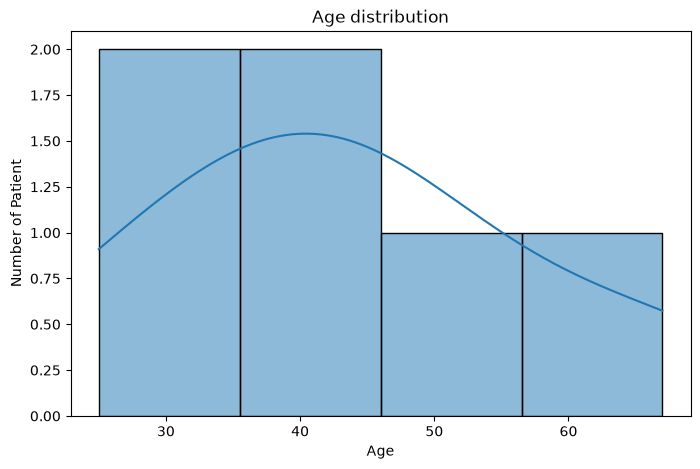

In [107]:
# Distribution lets see patient age distribution 
# kde is line
plt.figure(figsize=(8,5))

sns.histplot(df['age'], kde=True)

plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patient")

plt.savefig("../images/distribution_under_age.png")
plt.show()

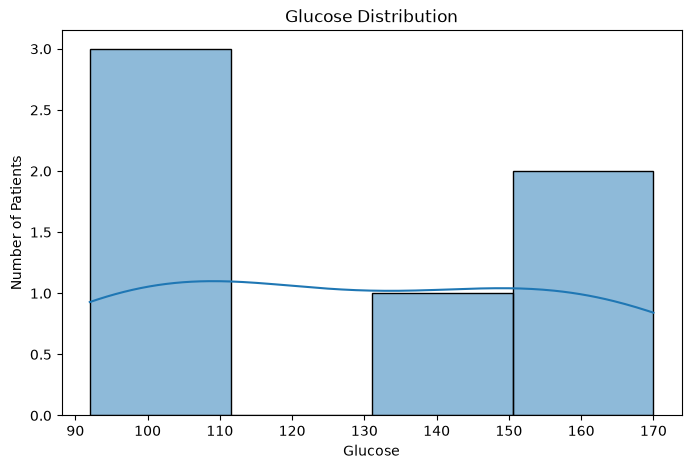

In [109]:
# BMI Distribution
plt.figure(figsize=(8, 5))

sns.histplot(df["glucose"], kde=True)

plt.title("Glucose Distribution")
plt.xlabel("Glucose")
plt.ylabel("Number of Patients")

plt.show()

In [110]:
# Correlation 
# Does age have a relationship with cholesterol?

cor_age_choles = df['age'].corr(df['cholesterol'])
print(f"Correlation between age and cholesterol: {cor_age_choles:.3f}")

Correlation between age and cholesterol: 0.635


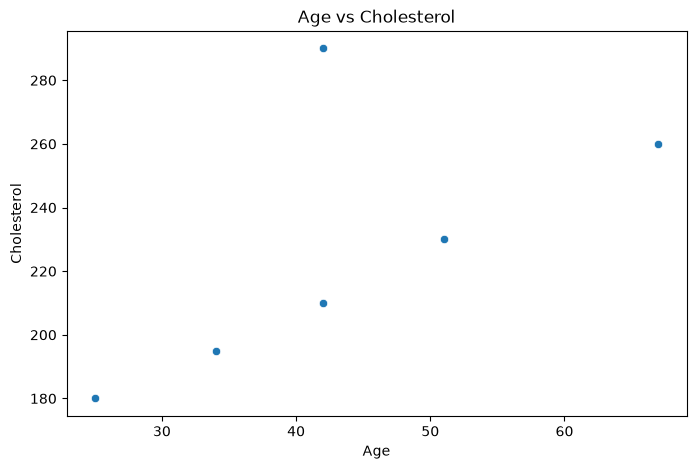

In [116]:
# visualize

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="age",
    y="cholesterol"
)

plt.title("Age vs Cholesterol")
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.show()

In [ ]:
# Interpretation

Correlation ranges from:

-1 → Strong negative relationship
 0 → No linear relationship
+1 → Strong positive relationship